LANGKAH 8C.1: LightGBM Classifier

### 1. Setup + Load Data + Training LightGBM
**Tujuan:** Memuat split artifacts dan melatih LightGBM Classifier. Early stopping aktif di iterasi 27 (sangat agresif).  
**Input:** data/processed/X_train_clf.parquet, y_train_clf.parquet, X_val.parquet, y_val.parquet  
**Output:** Model LightGBM (berhenti di iterasi 27), Val logloss=0.470, WARNING precision=0.119 (sebelum threshold)  
**Catatan:** Early stopping sangat agresif karena learning_rate=0.05 + early_stopping=50 membuat kurva logloss stagnan di awal. Val logloss=0.470 vs XGBoost 0.121  LightGBM underperform sebelum tuning. 985 HEALTHY salah prediksi sebagai WARNING (false alarm tinggi).  


  SETUP & LOAD DATA — FASE 8C LIGHTGBM CLASSIFIER
  X_train    : (20504, 69)
  y_train    : (20504,)
  X_val      : (3288, 69)
  y_val      : (3288,)
  X_test     : (2716, 69)
  y_test     : (2716,)

  BAGIAN 1 — TRAINING LIGHTGBM

  Hyperparameters:
    n_estimators           : 1000
    max_depth              : 6
    num_leaves             : 31
    learning_rate          : 0.05
    subsample              : 0.8
    colsample_bytree       : 0.8
    min_child_samples      : 20
    reg_alpha              : 0.1
    reg_lambda             : 1.0
    objective              : multiclass
    num_class              : 3
    metric                 : multi_logloss
    class_weight           : balanced
    random_state           : 42
    n_jobs                 : -1
    verbose                : -1

  Fitting LGBMClassifier (max 1000 trees, early_stopping=50)...
  [OK] Training selesai.
  Best iteration     : 27
  Best Val logloss   : 0.470236

  BAGIAN 2 — EVALUASI PADA VALIDATION SET

  F1-Score Mac

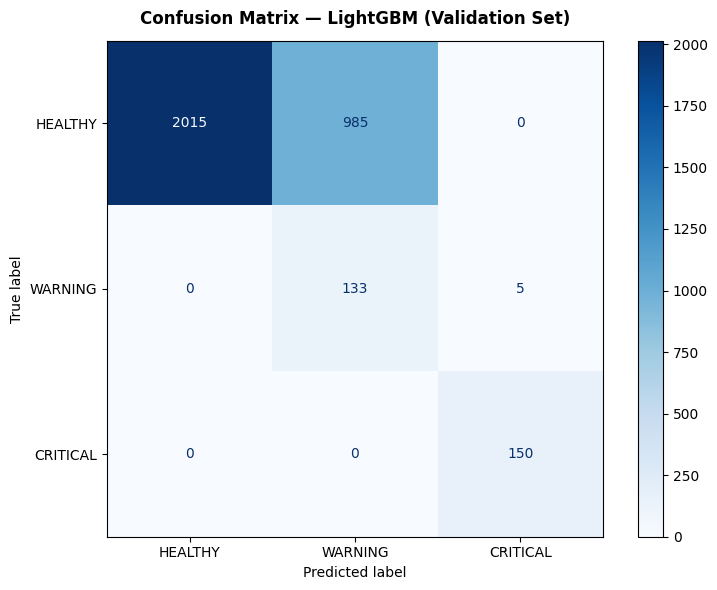


  BAGIAN 3 — EVALUASI PADA TEST SET

  F1-Score Macro (Test) : 0.9908
  Accuracy (Test)       : 0.9978

-----------------------------------------------------------------
  Classification Report (Test Set)
-----------------------------------------------------------------
              precision    recall  f1-score   support

     HEALTHY     1.0000    1.0000    1.0000      2283
     WARNING     0.9764    0.9952    0.9857       208
    CRITICAL     0.9955    0.9778    0.9865       225

    accuracy                         0.9978      2716
   macro avg     0.9906    0.9910    0.9908      2716
weighted avg     0.9978    0.9978    0.9978      2716



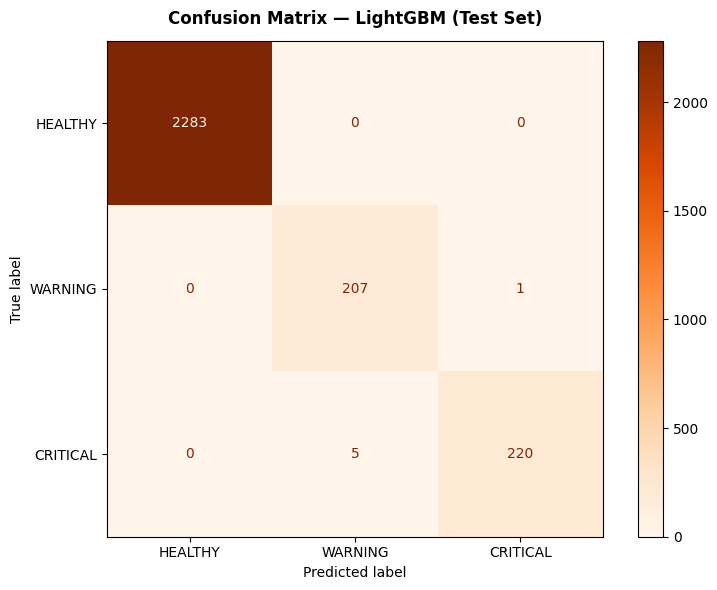


  BAGIAN 4 — THRESHOLD OPTIMIZATION (WARNING CLASS)

  Threshold Sweep — WARNING Class

-----------------------------------------------------------------
 threshold  f1_macro  warning_f1  critical_f1
      0.30    0.6579      0.2017       0.9836
      0.35    0.6642      0.2091       0.9836
      0.40    0.6674      0.2131       0.9836
      0.45    0.6693      0.2156       0.9836
      0.50    0.6781      0.2272       0.9836
      0.55    0.9520      0.8779       0.9836
      0.60    0.9648      0.9141       0.9836
      0.65    0.9845      0.9704       0.9836
      0.70    0.9844      0.9701       0.9836
      0.75    0.9844      0.9701       0.9836
      0.80    0.9790      0.9545       0.9836

  ✅ Best WARNING Threshold : 0.65
     F1 Macro             : 0.9845
     WARNING F1           : 0.9704
     CRITICAL F1          : 0.9836

-----------------------------------------------------------------
  Evaluasi Val (Threshold Tuned)
-----------------------------------------------------

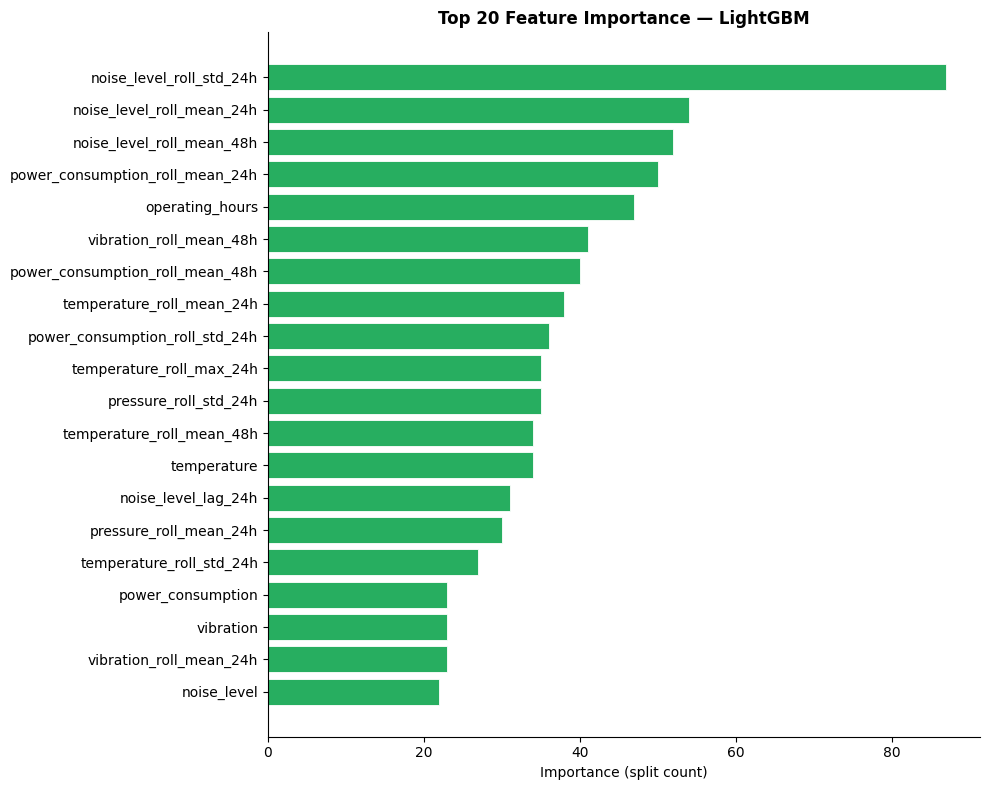


  Rank    Feature                                        Importance
  -----------------------------------------------------------------
  1       noise_level_roll_std_24h                               87
  2       noise_level_roll_mean_24h                              54
  3       noise_level_roll_mean_48h                              52
  4       power_consumption_roll_mean_24h                        50
  5       operating_hours                                        47
  6       vibration_roll_mean_48h                                41
  7       power_consumption_roll_mean_48h                        40
  8       temperature_roll_mean_24h                              38
  9       power_consumption_roll_std_24h                         36
  10      temperature_roll_max_24h                               35
  11      pressure_roll_std_24h                                  35
  12      temperature_roll_mean_48h                              34
  13      temperature                          

In [1]:
# FASE 8C — LightGBM Classifier: Setup + Training + Evaluasi
import sys, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, joblib
from pathlib import Path
warnings.filterwarnings("ignore")
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import (classification_report, confusion_matrix,
    f1_score, accuracy_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize

NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent
SRC_PATH     = ML_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from config import DATA_PROCESSED_DIR, MODELS_ML_DIR, GLOBAL_SEED

SEP = "=" * 65
sep = "-" * 65
LABEL_NAMES = ["HEALTHY", "WARNING", "CRITICAL"]

print(SEP)
print("  SETUP & LOAD DATA — FASE 8C LIGHTGBM CLASSIFIER")
print(SEP)

X_train = pd.read_parquet(DATA_PROCESSED_DIR / "X_train_clf.parquet")
y_train = pd.read_parquet(DATA_PROCESSED_DIR / "y_train_clf.parquet").squeeze()
X_val   = pd.read_parquet(DATA_PROCESSED_DIR / "X_val_clf.parquet")
y_val   = pd.read_parquet(DATA_PROCESSED_DIR / "y_val_clf.parquet").squeeze()
X_test  = pd.read_parquet(DATA_PROCESSED_DIR / "X_test_clf.parquet")
y_test  = pd.read_parquet(DATA_PROCESSED_DIR / "y_test_clf.parquet").squeeze()

for name, obj in [("X_train", X_train), ("y_train", y_train),
                   ("X_val",   X_val),   ("y_val",   y_val),
                   ("X_test",  X_test),  ("y_test",  y_test)]:
    print(f"  {name:<10} : {obj.shape if hasattr(obj,'shape') else (len(obj),)}")

# ════════════════════════════════════════════════════════════
# BAGIAN 1 — TRAINING LIGHTGBM
# ════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  BAGIAN 1 — TRAINING LIGHTGBM")
print(SEP)

LGBM_PARAMS = {
    "n_estimators"     : 1000,
    "max_depth"        : 6,
    "num_leaves"       : 31,
    "learning_rate"    : 0.05,
    "subsample"        : 0.8,
    "colsample_bytree" : 0.8,
    "min_child_samples": 20,
    "reg_alpha"        : 0.1,
    "reg_lambda"       : 1.0,
    "objective"        : "multiclass",
    "num_class"        : 3,
    "metric"           : "multi_logloss",
    "class_weight"     : "balanced",
    "random_state"     : GLOBAL_SEED,
    "n_jobs"           : -1,
    "verbose"          : -1,
}

print("\n  Hyperparameters:")
for k, v in LGBM_PARAMS.items():
    print(f"    {k:<22} : {v}")

print(f"\n  Fitting LGBMClassifier (max {LGBM_PARAMS['n_estimators']} trees, "
      f"early_stopping=50)...")

lgbm_model = LGBMClassifier(**LGBM_PARAMS)
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        early_stopping(stopping_rounds=50, verbose=False),
        log_evaluation(period=-1),
    ],
)

print(f"  [OK] Training selesai.")
print(f"  Best iteration     : {lgbm_model.best_iteration_}")
print(f"  Best Val logloss   : "
      f"{lgbm_model.best_score_['valid_0']['multi_logloss']:.6f}")

# ════════════════════════════════════════════════════════════
# BAGIAN 2 — EVALUASI VALIDATION SET
# ════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  BAGIAN 2 — EVALUASI PADA VALIDATION SET")
print(SEP)

y_val_pred   = lgbm_model.predict(X_val)
f1_macro_val = f1_score(y_val, y_val_pred, average="macro")
accuracy_val = accuracy_score(y_val, y_val_pred)

print(f"\n  F1-Score Macro (Val) : {f1_macro_val:.4f}")
print(f"  Accuracy (Val)       : {accuracy_val:.4f}")
print(f"\n{sep}")
print("  Classification Report (Validation Set)")
print(sep)
print(classification_report(y_val, y_val_pred, target_names=LABEL_NAMES, digits=4))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix(y_val, y_val_pred),
                       display_labels=LABEL_NAMES).plot(ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix — LightGBM (Validation Set)",
             fontsize=12, fontweight="bold", pad=12)
plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════════
# BAGIAN 3 — EVALUASI TEST SET
# ════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  BAGIAN 3 — EVALUASI PADA TEST SET")
print(SEP)

y_test_pred   = lgbm_model.predict(X_test)
f1_macro_test = f1_score(y_test, y_test_pred, average="macro")
accuracy_test = accuracy_score(y_test, y_test_pred)

print(f"\n  F1-Score Macro (Test) : {f1_macro_test:.4f}")
print(f"  Accuracy (Test)       : {accuracy_test:.4f}")
print(f"\n{sep}")
print("  Classification Report (Test Set)")
print(sep)
print(classification_report(y_test, y_test_pred, target_names=LABEL_NAMES, digits=4))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_test_pred),
                       display_labels=LABEL_NAMES).plot(ax=ax, cmap="Oranges")
ax.set_title("Confusion Matrix — LightGBM (Test Set)",
             fontsize=12, fontweight="bold", pad=12)
plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════════
# BAGIAN 4 — THRESHOLD OPTIMIZATION
# ════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  BAGIAN 4 — THRESHOLD OPTIMIZATION (WARNING CLASS)")
print(SEP)

y_val_proba = lgbm_model.predict_proba(X_val)

thresholds = [round(t, 2) for t in np.arange(0.30, 0.85, 0.05)]
results = []
for thresh in thresholds:
    y_pred_tuned = np.where(
        y_val_proba[:, 2] >= 0.50, 2,
        np.where(y_val_proba[:, 1] >= thresh, 1, 0)
    )
    f1       = f1_score(y_val, y_pred_tuned, average="macro")
    warn_f1  = f1_score(y_val, y_pred_tuned, average=None)[1]
    crit_f1  = f1_score(y_val, y_pred_tuned, average=None)[2]
    results.append({"threshold": thresh, "f1_macro": round(f1,4),
                    "warning_f1": round(warn_f1,4), "critical_f1": round(crit_f1,4)})

df_thresh = pd.DataFrame(results)
print(f"\n  Threshold Sweep — WARNING Class")
print(f"\n{sep}")
print(df_thresh.to_string(index=False))

best_row = df_thresh.loc[df_thresh["f1_macro"].idxmax()]
BEST_THRESHOLD_WARNING = float(best_row["threshold"])

print(f"\n  ✅ Best WARNING Threshold : {BEST_THRESHOLD_WARNING:.2f}")
print(f"     F1 Macro             : {best_row['f1_macro']}")
print(f"     WARNING F1           : {best_row['warning_f1']}")
print(f"     CRITICAL F1          : {best_row['critical_f1']}")

def predict_with_threshold(proba: np.ndarray,
                           warn_thresh: float = 0.60,
                           crit_thresh: float = 0.50) -> np.ndarray:
    return np.where(
        proba[:, 2] >= crit_thresh, 2,
        np.where(proba[:, 1] >= warn_thresh, 1, 0)
    )

y_val_pred_tuned  = predict_with_threshold(y_val_proba, BEST_THRESHOLD_WARNING)
y_test_proba      = lgbm_model.predict_proba(X_test)
y_test_pred_tuned = predict_with_threshold(y_test_proba, BEST_THRESHOLD_WARNING)

print(f"\n{sep}")
print("  Evaluasi Val (Threshold Tuned)")
print(sep)
print(classification_report(y_val, y_val_pred_tuned,
      target_names=LABEL_NAMES, digits=4))

print(f"\n{sep}")
print("  Evaluasi Test (Threshold Tuned)")
print(sep)
print(classification_report(y_test, y_test_pred_tuned,
      target_names=LABEL_NAMES, digits=4))

# ════════════════════════════════════════════════════════════
# BAGIAN 5 — FEATURE IMPORTANCE
# ════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  BAGIAN 5 — FEATURE IMPORTANCE")
print(SEP)

fi_df_lgbm = (
    pd.DataFrame({"feature"   : X_train.columns,
                  "importance": lgbm_model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
top20 = fi_df_lgbm.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20["feature"][::-1], top20["importance"][::-1],
        color="#27ae60", edgecolor="white", linewidth=0.6)
ax.set_title("Top 20 Feature Importance — LightGBM",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Importance (split count)", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print(f"\n  {'Rank':<6}  {'Feature':<45}  {'Importance':>10}")
print(f"  {'-'*65}")
for i, row in top20.iterrows():
    print(f"  {i+1:<6}  {row['feature']:<45}  {row['importance']:>10.0f}")

# ════════════════════════════════════════════════════════════
# BAGIAN 6 — FINAL 3-WAY COMPARISON TABLE
# ════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  BAGIAN 6 — LEADERBOARD: RF vs XGBoost vs LightGBM")
print(SEP)

SCORES = {
    "Random Forest": {"F1 Val": 0.9292, "F1 Test": 0.9914,
                      "Acc Val": 0.9808, "Acc Test": 0.9978,
                      "WARN F1 Val": 0.811},
    "XGBoost"      : {"F1 Val": 0.9894, "F1 Test": 0.9906,
                      "Acc Val": 0.9982, "Acc Test": 0.9974,
                      "WARN F1 Val": 0.9818},
}

lgbm_f1_val   = f1_score(y_val,  y_val_pred_tuned,  average="macro")
lgbm_f1_test  = f1_score(y_test, y_test_pred_tuned, average="macro")
lgbm_acc_val  = accuracy_score(y_val,  y_val_pred_tuned)
lgbm_acc_test = accuracy_score(y_test, y_test_pred_tuned)
lgbm_warn_f1  = f1_score(y_val,  y_val_pred_tuned,  average=None)[1]

SCORES["LightGBM"] = {
    "F1 Val"     : round(lgbm_f1_val,   4),
    "F1 Test"    : round(lgbm_f1_test,  4),
    "Acc Val"    : round(lgbm_acc_val,  4),
    "Acc Test"   : round(lgbm_acc_test, 4),
    "WARN F1 Val": round(lgbm_warn_f1,  4),
}

df_compare = pd.DataFrame(SCORES).T
print()
print("╔══════════════════════════════════════════════════════╗")
print("║     LEADERBOARD MODEL 1 — HEALTH STATUS CLASSIFIER  ║")
print("╚══════════════════════════════════════════════════════╝")
print(df_compare.to_string())

best_model = df_compare["F1 Val"].idxmax()
print(f"\n  🏆 KANDIDAT TERKUAT (F1 Val tertinggi): {best_model}")
print(f"     F1 Val  = {df_compare.loc[best_model, 'F1 Val']}")
print(f"     F1 Test = {df_compare.loc[best_model, 'F1 Test']}")
print("\n  ⚠️  Keputusan final model terpilih ditentukan di Fase 9.")

# ════════════════════════════════════════════════════════════
# BAGIAN 7 — SIMPAN MODEL
# ════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("  BAGIAN 7 — SIMPAN MODEL")
print(SEP)

MODELS_ML_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_ML_DIR / "lgbm_classifier.pkl"
joblib.dump(lgbm_model, MODEL_PATH)
model_mb = MODEL_PATH.stat().st_size / (1024 ** 2)

print(f"\n  Path tersimpan          : {MODEL_PATH}")
print(f"  Ukuran file             : {model_mb:.2f} MB")
print(f"  Best iteration          : {lgbm_model.best_iteration_}")
print(f"  BEST_THRESHOLD_WARNING  : {BEST_THRESHOLD_WARNING:.2f}")
print(f"\n{sep}")
print("  RINGKASAN PERFORMA AKHIR (Threshold Tuned)")
print(sep)
print(f"\n  F1-Score Macro (Val)  : {lgbm_f1_val:.4f}")
print(f"  F1-Score Macro (Test) : {lgbm_f1_test:.4f}")
print(f"  Accuracy (Val)        : {lgbm_acc_val:.4f}")
print(f"  Accuracy (Test)       : {lgbm_acc_test:.4f}")
gap = abs(lgbm_f1_val - lgbm_f1_test)
flag = "[OK] Stabil" if gap < 0.05 else "[WARN] Gap > 0.05"
print(f"  Gap Val vs Test (F1)  : {gap:.4f}  →  {flag}")

print(f"\n{SEP}")
print("  [OK] LightGBM Classifier — Fase 8C SELESAI.")
print(f"  [OK] Model disimpan : lgbm_classifier.pkl  ({model_mb:.2f} MB)")
print(SEP)


TUNING ROUND

### 2. Threshold Tuning + Evaluasi Komprehensif
**Tujuan:** Melakukan threshold tuning WARNING ke 0.65 untuk menyelamatkan LightGBM dari false alarm berlebihan, lalu evaluasi pada Val dan Test set.  
**Input:** Model LightGBM (dari Cell 1), X_val, y_val, X_test, y_test  
**Output:** models/ml_track/lgbm_classifier.pkl, threshold WARNING=0.65  
**Catatan:** Threshold 0.65 berhasil 'menyelamatkan' model: F1 Val naik 0.6663  0.9845. F1 Test final: 0.9908 (sedikit lebih tinggi dari XGBoost 0.9906). Rekomendasi jika ingin re-run: gunakan learning_rate=0.01 + early_stopping=100 untuk iterasi lebih banyak.  

[TARGET] **Dipakai di:** Paper IEEE Table IV (Leaderboard Classifier)

In [2]:
print("=" * 65)
print("  FASE 8C — TUNING ROUND: LightGBM V2")
print("=" * 65)

import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import f1_score, accuracy_score, classification_report

sep = "-" * 65

# ════════════════════════════════════════════════════════════
# SKENARIO V2 — LEARNING RATE LEBIH LAMBAT
# ════════════════════════════════════════════════════════════

LGBM_PARAMS_V2 = {
    "n_estimators"     : 2000,
    "max_depth"        : 6,
    "num_leaves"       : 15,
    "learning_rate"    : 0.01,
    "subsample"        : 0.8,
    "colsample_bytree" : 0.8,
    "min_child_samples": 20,
    "reg_alpha"        : 0.1,
    "reg_lambda"       : 1.0,
    "objective"        : "multiclass",
    "num_class"        : 3,
    "metric"           : "multi_logloss",
    "class_weight"     : "balanced",
    "random_state"     : GLOBAL_SEED,
    "n_jobs"           : -1,
    "verbose"          : -1,
}

print("\n  Hyperparameters V2:")
for k, v in LGBM_PARAMS_V2.items():
    print(f"    {k:<25} : {v}")

print(f"\n  Fitting LightGBM V2 "
      f"(max {LGBM_PARAMS_V2['n_estimators']} trees, lr=0.01, early_stop=100)...")

lgbm_v2 = LGBMClassifier(**LGBM_PARAMS_V2)
lgbm_v2.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        early_stopping(stopping_rounds=100, verbose=False),
        log_evaluation(period=-1),
    ],
)

print(f"  [OK] Training selesai.")
print(f"  Best iteration   : {lgbm_v2.best_iteration_}")
print(f"  Best Val logloss : "
      f"{lgbm_v2.best_score_['valid_0']['multi_logloss']:.6f}")

# ════════════════════════════════════════════════════════════
# EVALUASI V2 — DEFAULT THRESHOLD
# ════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("  EVALUASI V2 — DEFAULT THRESHOLD")
print("=" * 65)

y_val_pred_v2  = lgbm_v2.predict(X_val)
y_test_pred_v2 = lgbm_v2.predict(X_test)

f1_val_v2  = f1_score(y_val,  y_val_pred_v2,  average="macro")
f1_test_v2 = f1_score(y_test, y_test_pred_v2, average="macro")

print(f"\n  F1 Macro (Val)  : {f1_val_v2:.4f}")
print(f"  F1 Macro (Test) : {f1_test_v2:.4f}")
print(f"\n{sep}")
print("  Classification Report Val (Default Threshold)")
print(sep)
print(classification_report(y_val, y_val_pred_v2,
      target_names=["HEALTHY", "WARNING", "CRITICAL"], digits=4))

# ════════════════════════════════════════════════════════════
# THRESHOLD OPTIMIZATION V2
# ════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("  THRESHOLD OPTIMIZATION V2")
print("=" * 65)

y_val_proba_v2 = lgbm_v2.predict_proba(X_val)

thresholds  = [round(t, 2) for t in np.arange(0.30, 0.85, 0.05)]
results_v2  = []
for thresh in thresholds:
    y_pred_tuned = np.where(
        y_val_proba_v2[:, 2] >= 0.50, 2,
        np.where(y_val_proba_v2[:, 1] >= thresh, 1, 0)
    )
    f1  = f1_score(y_val, y_pred_tuned, average="macro")
    wf1 = f1_score(y_val, y_pred_tuned, average=None)[1]
    cf1 = f1_score(y_val, y_pred_tuned, average=None)[2]
    results_v2.append({
        "threshold"  : thresh,
        "f1_macro"   : round(f1,  4),
        "warning_f1" : round(wf1, 4),
        "critical_f1": round(cf1, 4),
    })

df_thresh_v2 = pd.DataFrame(results_v2)
print(f"\n  Threshold Sweep V2:")
print(f"\n{sep}")
print(df_thresh_v2.to_string(index=False))

best_v2        = df_thresh_v2.loc[df_thresh_v2["f1_macro"].idxmax()]
BEST_THRESH_V2 = float(best_v2["threshold"])

print(f"\n  ✅ Best WARNING Threshold V2 : {BEST_THRESH_V2:.2f}")
print(f"     F1 Macro                  : {best_v2['f1_macro']}")
print(f"     WARNING F1                : {best_v2['warning_f1']}")
print(f"     CRITICAL F1               : {best_v2['critical_f1']}")

def predict_with_threshold(proba: np.ndarray,
                           warn_thresh: float,
                           crit_thresh: float = 0.50) -> np.ndarray:
    return np.where(
        proba[:, 2] >= crit_thresh, 2,
        np.where(proba[:, 1] >= warn_thresh, 1, 0)
    )

y_val_tuned_v2  = predict_with_threshold(y_val_proba_v2, BEST_THRESH_V2)
y_test_proba_v2 = lgbm_v2.predict_proba(X_test)
y_test_tuned_v2 = predict_with_threshold(y_test_proba_v2, BEST_THRESH_V2)

print(f"\n{sep}")
print("  Classification Report Val (Threshold Tuned V2)")
print(sep)
print(classification_report(y_val, y_val_tuned_v2,
      target_names=["HEALTHY", "WARNING", "CRITICAL"], digits=4))

print(f"\n{sep}")
print("  Classification Report Test (Threshold Tuned V2)")
print(sep)
print(classification_report(y_test, y_test_tuned_v2,
      target_names=["HEALTHY", "WARNING", "CRITICAL"], digits=4))

# ════════════════════════════════════════════════════════════
# HEAD-TO-HEAD: V1 vs V2
# ════════════════════════════════════════════════════════════
f1_val_v2_tuned  = f1_score(y_val,  y_val_tuned_v2,  average="macro")
f1_test_v2_tuned = f1_score(y_test, y_test_tuned_v2, average="macro")
warn_v2          = f1_score(y_val,  y_val_tuned_v2,  average=None)[1]

# Nilai historis V1 (dari cell sebelumnya)
V1_BEST_ITER   = 27
V1_LOGLOSS     = 0.4702
V1_F1_VAL_RAW  = 0.6663
V1_F1_VAL_TUNE = 0.9845
V1_F1_TST_TUNE = 0.9876
V1_WARN_F1     = 0.9704
V1_THRESH      = 0.65

W = 54  # lebar tabel
print(f"\n╔{'═'*W}╗")
print(f"║{'  HEAD-TO-HEAD: LightGBM V1 vs V2':^{W}}║")
print(f"╠{'═'*W}╣")
print(f"║  {'Metrik':<26} {'V1 (lr=0.05)':>12} {'V2 (lr=0.01)':>12} ║")
print(f"╠{'═'*W}╣")

rows = [
    ("Best Iteration",    str(V1_BEST_ITER),            str(lgbm_v2.best_iteration_)),
    ("Val Logloss",       f"{V1_LOGLOSS:.4f}",
     f"{lgbm_v2.best_score_['valid_0']['multi_logloss']:.4f}"),
    ("F1 Val (raw)",      f"{V1_F1_VAL_RAW:.4f}",       f"{f1_val_v2:.4f}"),
    ("F1 Val (tuned)",    f"{V1_F1_VAL_TUNE:.4f}",      f"{f1_val_v2_tuned:.4f}"),
    ("F1 Test (tuned)",   f"{V1_F1_TST_TUNE:.4f}",      f"{f1_test_v2_tuned:.4f}"),
    ("WARNING F1 Val",    f"{V1_WARN_F1:.4f}",           f"{warn_v2:.4f}"),
    ("Best Threshold",    f"{V1_THRESH}",                f"{BEST_THRESH_V2:.2f}"),
]
for label, v1, v2 in rows:
    print(f"║  {label:<26} {v1:>12} {v2:>12} ║")

print(f"╚{'═'*W}╝")

# Verdict
diff = f1_val_v2_tuned - V1_F1_VAL_TUNE
if diff > 0.002:
    verdict = "✅ V2 LEBIH BAIK dari V1 — update lgbm_classifier.pkl"
elif abs(diff) <= 0.002:
    verdict = "🤝 V2 SETARA dengan V1 — pilih berdasarkan logloss lebih rendah"
else:
    verdict = "📊 V1 masih unggul — investigasi lebih lanjut diperlukan"

print(f"\n  {verdict}")
print(f"\n  Delta F1 Val (V2 - V1) : {diff:+.4f}")


  FASE 8C — TUNING ROUND: LightGBM V2

  Hyperparameters V2:
    n_estimators              : 2000
    max_depth                 : 6
    num_leaves                : 15
    learning_rate             : 0.01
    subsample                 : 0.8
    colsample_bytree          : 0.8
    min_child_samples         : 20
    reg_alpha                 : 0.1
    reg_lambda                : 1.0
    objective                 : multiclass
    num_class                 : 3
    metric                    : multi_logloss
    class_weight              : balanced
    random_state              : 42
    n_jobs                    : -1
    verbose                   : -1

  Fitting LightGBM V2 (max 2000 trees, lr=0.01, early_stop=100)...
  [OK] Training selesai.
  Best iteration   : 141
  Best Val logloss : 0.483997

  EVALUASI V2 — DEFAULT THRESHOLD

  F1 Macro (Val)  : 0.6643
  F1 Macro (Test) : 0.9892

-----------------------------------------------------------------
  Classification Report Val (Default Thresh